    Import delle librerie

In [1]:
import json
import pandas as pd
from pathlib import Path

    Individuazione della cartella principale

    Individuazione del file message_1.json

Ogni file rappresenta una conversazione esportata da Instagram e contiene i messaggi scambiati, i partecipanti e i relativi metadati. 
Per motivi di privacy, l'elenco completo dei percorsi non viene riportato nel notebook.

    Esplorazione della struttura del Dataset

In [23]:
message_files = list(base.rglob("message_1.json"))

with open(message_files[0], encoding="utf-8") as f:
    data = json.load(f)

print(data.keys())

dict_keys(['participants', 'messages', 'title', 'is_still_participant', 'thread_path', 'magic_words', 'is_pending'])


Dopo aver individuato i file message_1.json, è stata analizzata la struttura interna dei dati.
Ogni conversazione contiene informazioni sui partecipanti, i messaggi scambiati e alcuni metadati associati alla conversazione.

     Analisi delle conversazioni

Dopo aver identificato la struttura dei file JSON , è stato sviluppato uno script per attraversare tutte le conversazioni presenti nella cartella inbox ed estrarre tutte le informazioni necessarie all'analisi quantitativa

In [ ]:
import json
from pathlib import Path
import pandas as pd

BASE = Path(r"C:\Users\rebec\Downloads\instagram-rebeccamarianini-2026-06-02-4g40s6H3\your_instagram_activity\messages\inbox")

rows = []

for chat in BASE.iterdir():
    if not chat.is_dir():
        continue

    total = 0

    for f in chat.glob("message_*.json"):
        try:
            with open(f, encoding="utf-8") as fp:
                data = json.load(fp)

            total += len(data.get("messages", []))

        except Exception:
            pass

    rows.append({
        "chat": chat.name,
        "messaggi": total
    })

df = pd.DataFrame(rows)
df = df.sort_values("messaggi", ascending=False)

print(df.head(20))

L'output originale è stato omesso per motivi di privacy, poiché conteneva riferimenti a conversazioni e identificativi riconducibili a utenti reali. Questa fase è stata utilizzata esclusivamente per verificare la corretta estrazione e aggregazione dei dati.

    Analisi temporale dei messaggi

A partire dai timestamp associati ai messaggi esportati da Instagram, è stato calcolato il numero di messaggi scambiati per ciascun anno.

I risultati sono stati aggregati e rappresentati mediante un grafico lineare per evidenziare l'andamento dell'attività comunicativa nel tempo.

Messaggi totali: 120867

    Anno  Messaggi
0   2014         7
1   2015       319
2   2016      3737
3   2017     10430
4   2018      7169
5   2019     13461
6   2020      8841
7   2021      1654
8   2022      6982
9   2023     14762
10  2024     21798
11  2025     25232
12  2026      6475


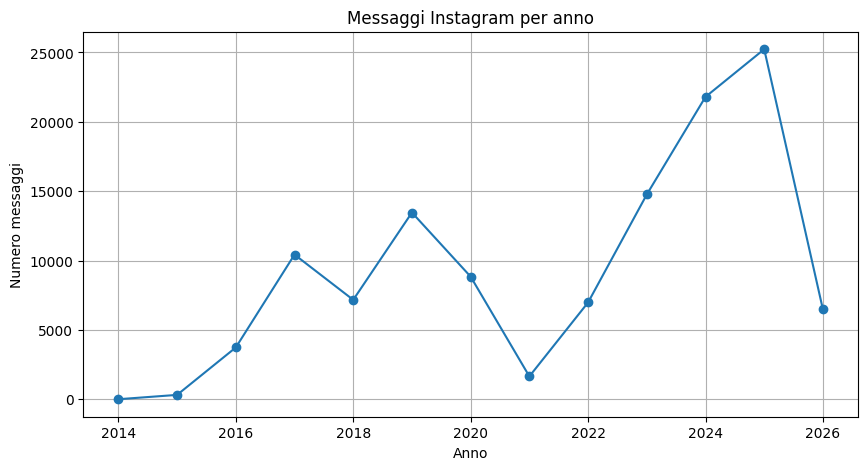

In [75]:
import json
from pathlib import Path
from datetime import datetime
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt

BASE = Path(
    r"C:\Users\rebec\Downloads\instagram-rebeccamarianini-2026-06-02-4g40s6H3\your_instagram_activity\messages\inbox"
)

anni = Counter()

for chat in BASE.iterdir():

    if not chat.is_dir():
        continue

    for f in chat.glob("message_*.json"):

        try:
            with open(f, encoding="utf-8") as fp:
                data = json.load(fp)

            for msg in data.get("messages", []):

                if "timestamp_ms" not in msg:
                    continue

                anno = datetime.fromtimestamp(
                    msg["timestamp_ms"] / 1000
                ).year

                anni[anno] += 1

        except Exception:
            pass

df_messaggi = pd.DataFrame(
    sorted(anni.items()),
    columns=["Anno", "Messaggi"]
)

print("Messaggi totali:", df_messaggi["Messaggi"].sum())
print()
print(df_messaggi)

plt.figure(figsize=(10,5))

plt.plot(
    df_messaggi["Anno"],
    df_messaggi["Messaggi"],
    marker="o"
)

plt.title("Messaggi Instagram per anno")
plt.xlabel("Anno")
plt.ylabel("Numero messaggi")
plt.grid(True)

plt.show()

    Attività mensile dei messaggi

I messaggi sono stati aggregati per mese e anno e rappresentati mediante una heatmap. 
L'intensità del colore indica il numero di messaggi scambiati, consentendo di individuare rapidamente i periodi caratterizzati da una maggiore o minore attività comunicativa.

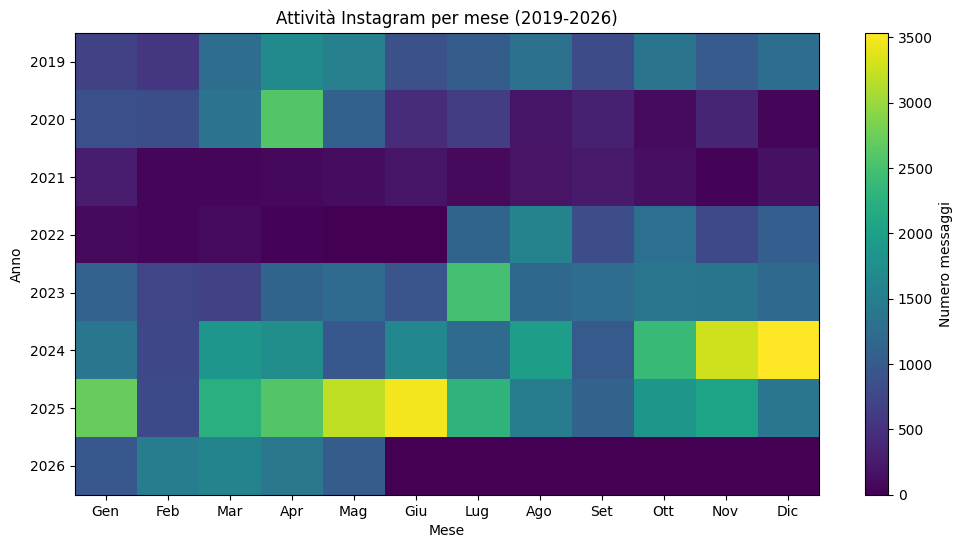

In [35]:
from pathlib import Path
import json
from datetime import datetime
from collections import defaultdict
import pandas as pd
import matplotlib.pyplot as plt

BASE = Path(r"C:\Users\rebec\Downloads\instagram-rebeccamarianini-2026-06-02-4g40s6H3\your_instagram_activity\messages\inbox")

conteggi = defaultdict(int)

for chat in BASE.iterdir():

    if not chat.is_dir():
        continue

    for file in chat.glob("message_*.json"):

        try:

            with open(file, encoding="utf-8") as f:
                data = json.load(f)

            for msg in data.get("messages", []):

                ts = msg.get("timestamp_ms")

                if not ts:
                    continue

                dt = datetime.fromtimestamp(ts / 1000)

                if dt.year < 2019:
                    continue

                conteggi[(dt.year, dt.month)] += 1

        except:
            pass

rows = []

for (anno, mese), n in conteggi.items():

    rows.append({
        "anno": anno,
        "mese": mese,
        "messaggi": n
    })

df = pd.DataFrame(rows)

heat = df.pivot(
    index="anno",
    columns="mese",
    values="messaggi"
).fillna(0)

mesi = [
    "Gen", "Feb", "Mar", "Apr",
    "Mag", "Giu", "Lug", "Ago",
    "Set", "Ott", "Nov", "Dic"
]

plt.figure(figsize=(12, 6))

plt.imshow(
    heat,
    aspect="auto"
)

plt.colorbar(label="Numero messaggi")

plt.xticks(
    range(12),
    mesi
)

plt.yticks(
    range(len(heat.index)),
    heat.index
)

plt.title("Attività Instagram per mese (2019-2026)")

plt.xlabel("Mese")
plt.ylabel("Anno")

plt.show()

    Analisi dei contenuti salvati

È stata effettuata una verifica della struttura del file saved_posts.json al fine di identificare i campi disponibili , valutare la qualità e la quantità dei dati esportati.

In [53]:
print(type(data))
print(len(data))
print(data[0].keys())

<class 'list'>
4269
dict_keys(['timestamp', 'media', 'label_values', 'fbid'])


    Distribuzione temporale dei contenuti salvati

A partire dalla data associata a ciascun contenuto, è stato calcolato il numero di elementi salvati per ogni anno.

I risultati sono stati successivamente aggregati e rappresentati mediante un grafico temporale.

    anno  salvataggi
0   2016          18
1   2017         542
2   2018         248
3   2019         760
4   2020         842
5   2021         322
6   2022         147
7   2023         197
8   2024         360
9   2025         599
10  2026         234


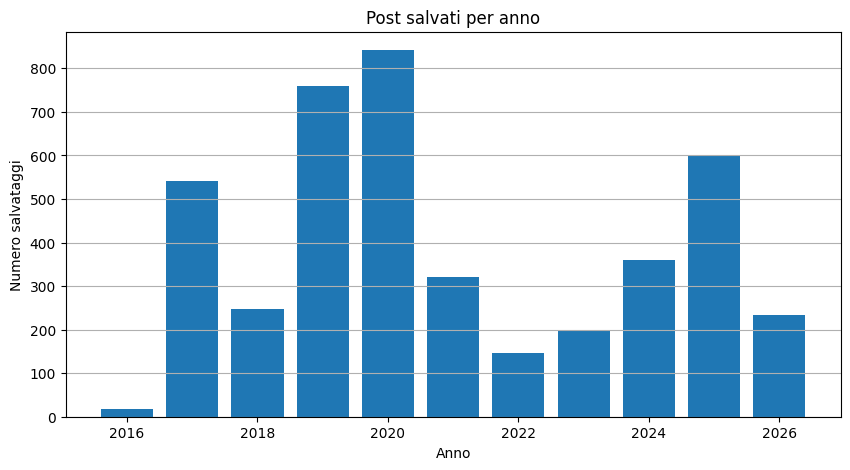

In [57]:
import json
from pathlib import Path
from datetime import datetime
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt

FILE = Path(
    r"C:\Users\rebec\Downloads\instagram-rebeccamarianini-2026-06-02-4g40s6H3\your_instagram_activity\saved\saved_posts.json"
)

with open(FILE, encoding="utf-8") as f:
    data = json.load(f)

anni = Counter()

for post in data:

    try:
        anno = datetime.fromtimestamp(
            post["timestamp"]
        ).year

        anni[anno] += 1

    except:
        pass

df = pd.DataFrame(
    sorted(anni.items()),
    columns=["anno", "salvataggi"]
)

print(df)

plt.figure(figsize=(10,5))

plt.bar(
    df["anno"],
    df["salvataggi"]
)

plt.title("Post salvati per anno")
plt.xlabel("Anno")
plt.ylabel("Numero salvataggi")

plt.grid(axis="y")

plt.show()

    Analisi dei contenuti apprezzati

È stata effettuata una verifica della struttura del file liked_posts.json al fine di identificare i campi disponibili e valutare la quantità dei dati esportati.

In [68]:
from pathlib import Path
import json

FILE = Path(
    r"C:\Users\rebec\Downloads\instagram-rebeccamarianini-2026-06-02-4g40s6H3\your_instagram_activity\likes\liked_posts.json"
)

with open(FILE, encoding="utf-8") as f:
    data = json.load(f)

print(type(data))
print("Like totali:", len(data))
print(data[0].keys())

<class 'list'>
Like totali: 47759
dict_keys(['timestamp', 'media', 'label_values', 'fbid'])


La verifica ha evidenziato la presenza di 47.759 contenuti apprezzati. 
Ogni record contiene informazioni temporali (timestamp) e metadati associati al contenuto con cui è stata registrata un'interazione positiva.

    Distribuzione temporale dei like
A partire dalla data associata a ciascun contenuto apprezzato, è stato calcolato il numero di like registrati per ogni anno.

I risultati sono stati successivamente aggregati e rappresentati mediante un grafico temporale, utile per evidenziare l'evoluzione dell'attività sulla piattaforma nel tempo.

    anno  like
0   2014   917
1   2015  1933
2   2016  4875
3   2017  7697
4   2018  2334
5   2019  2476
6   2020  2335
7   2021  2195
8   2022  1525
9   2023  1786
10  2024  9817
11  2025  6597
12  2026  3272


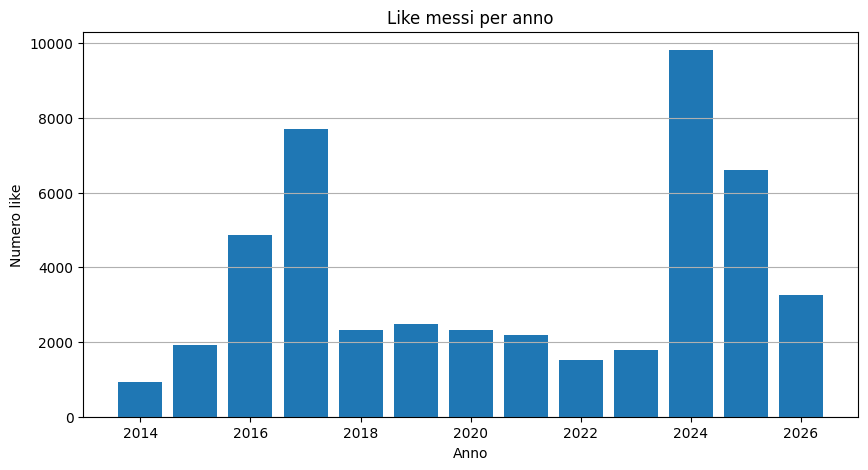

In [9]:
import json
from pathlib import Path
from datetime import datetime
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt

FILE = Path(
    r"C:\Users\rebec\Downloads\instagram-rebeccamarianini-2026-06-02-4g40s6H3\your_instagram_activity\likes\liked_posts.json"
)

with open(FILE, encoding="utf-8") as f:
    data = json.load(f)

anni = Counter()

for post in data:

    try:
        anno = datetime.fromtimestamp(
            post["timestamp"]
        ).year

        anni[anno] += 1

    except:
        pass

df = pd.DataFrame(
    sorted(anni.items()),
    columns=["anno", "like"]
)

print(df)

plt.figure(figsize=(10,5))

plt.bar(
    df["anno"],
    df["like"]
)

plt.title("Like messi per anno")
plt.xlabel("Anno")
plt.ylabel("Numero like")

plt.grid(axis="y")

plt.show()

    Individuazione dei file contenenti i followers
È stato effettuato il caricamento dei file followers_1.json e followers_2.json, contenenti l'elenco dei follower associati all'account al momento dell'esportazione dei dati.

In [3]:
from pathlib import Path

BASE = Path(
    r"C:\Users\rebec\Downloads\instagram-rebeccamarianini-2026-06-02-4g40s6H3\connections\followers_and_following"
)

for f in BASE.iterdir():
    if "followers" in f.name:
        print(f.name)

followers_1.json
followers_2.json


    Costruzione del dataset dei followers

Dopo aver individuato i file rilevanti, è stato sviluppato uno script per caricare e aggregare le informazioni contenute nei file followers_1.json e followers_2.json, ottenendo l'elenco completo dei follower presenti al momento dell'esportazione.

In [24]:
import json
from pathlib import Path

BASE = Path(
    r"C:\Users\rebec\Downloads\instagram-rebeccamarianini-2026-06-02-4g40s6H3\connections\followers_and_following"
)

# FOLLOWERS
followers = set()

for file in ["followers_1.json", "followers_2.json"]:

    with open(BASE / file, encoding="utf-8") as f:
        data = json.load(f)

    for item in data:
        try:
            followers.add(
                item["string_list_data"][0]["value"]
            )
        except:
            pass

print("Follower caricati:", len(followers))

# FOLLOWING
with open(BASE / "following.json", encoding="utf-8") as f:
    data = json.load(f)

print("\nCHIAVI DEL FILE:")
print(data.keys())

print("\nNumero account seguiti:")
print(len(data["relationships_following"]))

Follower caricati: 19007

CHIAVI DEL FILE:
dict_keys(['relationships_following'])

Numero account seguiti:
608


    Verifica dei file follower

È stato effettuato il caricamento dei file followers_1.json e followers_2.json contenenti i dati dei follower esportati da Instagram.

La verifica preliminare ha evidenziato la presenza di 10.000 record nel primo file e 9.007 record nel secondo, per un totale di 19.007 follower.

In [42]:
import json
from pathlib import Path

BASE = Path(
    r"C:\Users\rebec\Downloads\instagram-rebeccamarianini-2026-06-02-4g40s6H3\connections\followers_and_following"
)

for file in ["followers_1.json", "followers_2.json"]:
    with open(BASE / file, encoding="utf-8") as f:
        data = json.load(f)

    print(file, "->", len(data))

followers_1.json -> 10000
followers_2.json -> 9007


    Distribuzione temporale dei follower

Per ciascun follower è stato estratto il timestamp associato alla data di acquisizione.
I timestamp sono stati convertiti in date e aggregati per anno, al fine di analizzare l'evoluzione della crescita del profilo nel tempo.
I risultati sono rappresentati mediante un grafico a barre che mostra il numero di follower acquisiti per ciascun anno.

2014      108
2015      427
2016      509
2017      237
2018      142
2019      181
2020      149
2021       45
2022       83
2023      182
2024     1777
2025     4082
2026    11085
Name: count, dtype: int64


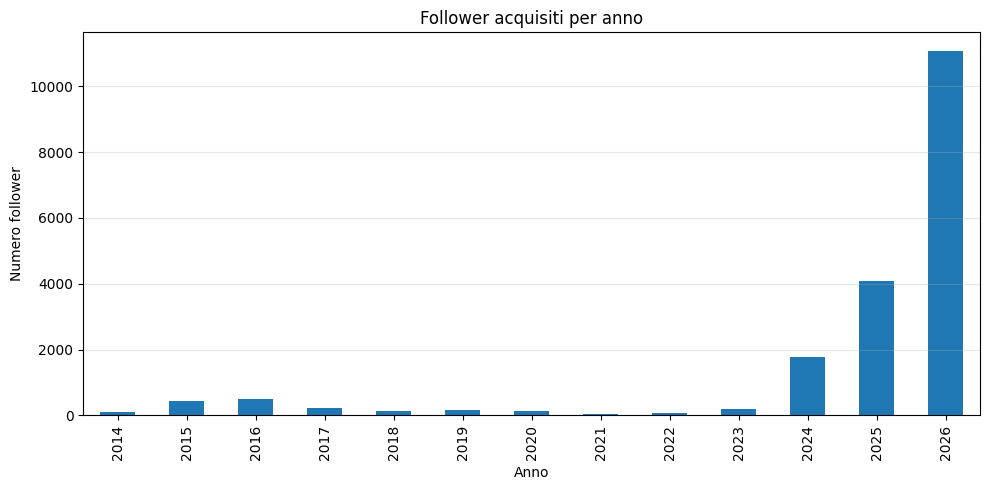

In [13]:
import json
import pandas as pd
import matplotlib.pyplot as plt

files = [
    r".\Downloads\instagram-rebeccamarianini-2026-06-02-4g40s6H3\connections\followers_and_following\followers_1.json",
    r".\Downloads\instagram-rebeccamarianini-2026-06-02-4g40s6H3\connections\followers_and_following\followers_2.json"
]

timestamps = []

for file in files:
    with open(file, "r", encoding="utf-8") as f:
        data = json.load(f)

    for follower in data:
        try:
            ts = follower["string_list_data"][0]["timestamp"]
            timestamps.append(ts)
        except:
            pass

# conversione timestamp -> data
dates = pd.to_datetime(timestamps, unit="s")

# follower acquisiti per anno
followers_per_year = dates.year.value_counts().sort_index()

print(followers_per_year)

plt.figure(figsize=(10,5))
followers_per_year.plot(kind="bar")
plt.title("Follower acquisiti per anno")
plt.xlabel("Anno")
plt.ylabel("Numero follower")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

    Analisi dei contenuti pubblicati

Per comprendere la struttura dei dati relativi ai contenuti pubblicati, è stato aperto il file posts_1.json e ne sono stati ispezionati i primi elementi, verificando il formato e i campi disponibili per l'analisi.

In [26]:
import json

with open(
    r"C:\Users\rebec\Downloads\instagram-rebeccamarianini-2026-06-02-4g40s6H3\your_instagram_activity\media\posts_1.json",
    "r",
    encoding="utf-8"
) as f:
    data = json.load(f)

print(type(data))
print(data[0].keys())

<class 'list'>
dict_keys(['media', 'title', 'creation_timestamp'])


La verifica preliminare ha mostrato che il dataset è organizzato come una lista di elementi. Ogni record contiene informazioni relative al contenuto pubblicato, tra cui i dati multimediali associati, il titolo e la data di pubblicazione.

    Analisi dei contenuti archiviati
È stata effettuata un'esplorazione preliminare del file archived_posts.json al fine di identificarne la struttura interna e i campi disponibili per l'analisi.

In [18]:
for k in data.keys():
    print(k)

ig_archived_post_media


Esplorazione della struttura del file archived_posts.json. È stata identificata la chiave contenente i dati relativi ai post archiviati.

In [19]:
print(len(data["ig_archived_post_media"]))

529


L'analisi preliminare ha evidenziato la presenza di 529 contenuti archiviati

    Analisi dei post pubblicati

I contenuti presenti nel file archived_posts.json corrispondono a post precedentemente pubblicati e successivamente archiviati.
L'analisi di tali dati consente di ricostruire una parte dell'attività di pubblicazione dell'account nel tempo.

I post sono stati aggregati per anno sulla base della data di pubblicazione e rappresentati mediante un grafico temporale.

2015      4
2016     19
2017     50
2018    116
2019     84
2020     32
2021     24
2022    110
2023     58
2024     28
2025      1
2026      3
Name: count, dtype: int64


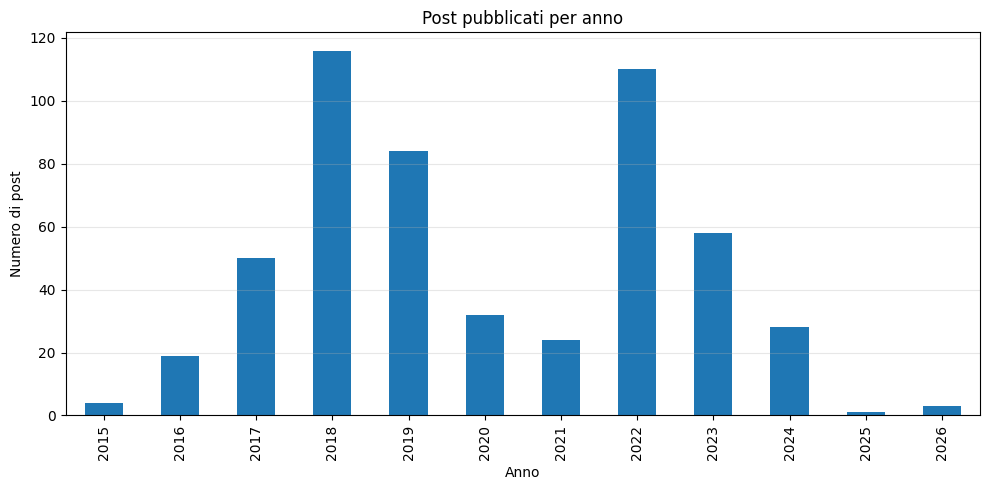

In [38]:
import json
import pandas as pd
import matplotlib.pyplot as plt

with open(
    r".\Downloads\instagram-rebeccamarianini-2026-06-02-4g40s6H3\your_instagram_activity\media\archived_posts.json",
    "r",
    encoding="utf-8"
) as f:
    data = json.load(f)

posts = data["ig_archived_post_media"]

timestamps = []

for post in posts:

    if "creation_timestamp" in post:
        timestamps.append(post["creation_timestamp"])

    elif (
        "media" in post
        and len(post["media"]) > 0
        and "creation_timestamp" in post["media"][0]
    ):
        timestamps.append(
            post["media"][0]["creation_timestamp"]
        )

dates = pd.to_datetime(timestamps, unit="s")

posts_per_year = dates.year.value_counts().sort_index()

print(posts_per_year)

plt.figure(figsize=(10,5))
posts_per_year.plot(kind="bar")

plt.title("Post pubblicati per anno")
plt.xlabel("Anno")
plt.ylabel("Numero di post")

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()